In [1]:
import numpy as np
from matplotlib import pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## 模拟梯度下降

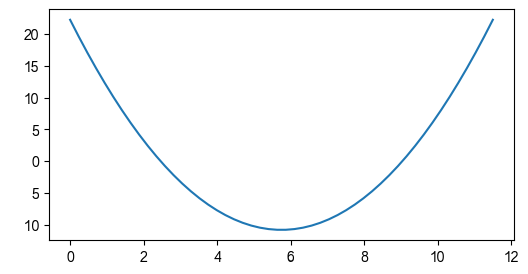

In [2]:
f = lambda x : (x - 3.5) ** 2 - 4.5 * x + 10
# 导函数
g = lambda x : 2 * (x - 3.5) - 4.5

plt.figure(figsize = (6, 3))
X = np.linspace(0, 11.5)
plt.plot(X, f(X))

开始点: 3


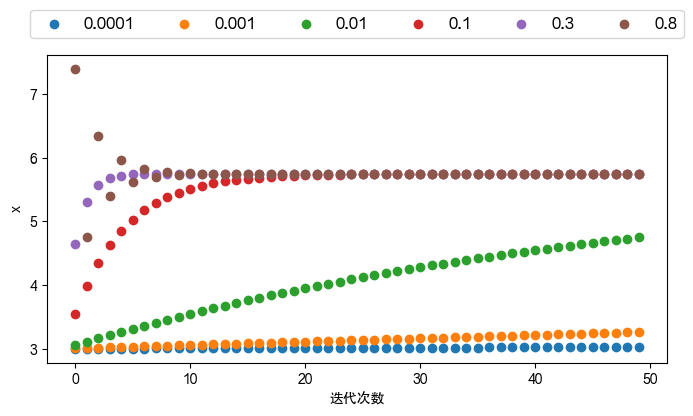

In [3]:
#梯度下降，迭代次数为 times，eta 为学习率，start 为初始值
def update(eta, start=0, times=1000):
    #假设起始值相同
    x = start
    #记录所有变化的 x
    res = []
    for i in range(times):
        x = x - eta * g(x)
        res.append(x)
    return np.array(res)

plt.figure(figsize = (8, 4))

#----------------------------------------

start_x = np.random.randint(0, 12, size = 1)[0]
print('开始点:', start_x)

# 多个学习率
etas = [0.0001, 0.001, 0.01, 0.1, 0.3, 0.8]

# 查看每个学习率下单变量 x 的收敛情况
for e in etas:
    times = 50
    plt.scatter(np.arange(times), update(e, start = start_x, times = times))

#----------------------------------------

plt.xlabel('迭代次数')
plt.ylabel('x')

#图例
_ = plt.legend(etas, 
           fontsize=12,
           loc='center', 
           ncol=6, 
           bbox_to_anchor=[0.5, 1.1])

## 三种梯度下降方法实战

### BGD 批量梯度下降

<font color=green size=6>$\theta^{t+1} = \theta^t - \alpha * X^T(X\theta - y)$</font>

$X 形状为 (m, n+1)$

$\theta 形状为 (n+1, 1) $

$y 形状为 (m, 1)$

$X^T(X\theta - y) 形状为 (n+1, 1)$

#### 一元一次线性回归

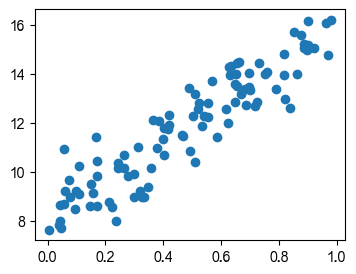

In [4]:
X = np.random.rand(100, 1)
w, b = np.random.randint(1, 10, size = 2)

y = w * X + b + np.random.randn(100, 1)

plt.figure(figsize = (4, 3))
_ = plt.scatter(X, y)

In [5]:
X = np.concatenate([X, np.full(shape = (100, 1), fill_value = 1)], axis = 1)
X.shape

(100, 2)

真实的斜率和截距为 8 8
求出的斜率和截距为 [7.74029459 8.13054632]


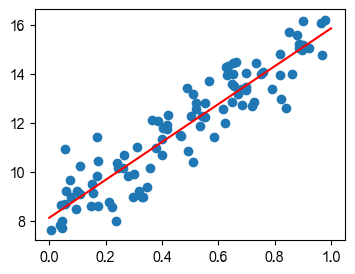

In [6]:
epoches = 10000
eta = 0.01

#要求解的系数
theta = np.random.randn(2, 1)

for i in range(epoches):
    #计算梯度
    g = X.T @ (X @ theta - y)
    #更新 theta
    theta = theta - eta * g

print('真实的斜率和截距为', w, b)
print('求出的斜率和截距为', theta.flatten())

# ------------------------

plt.figure(figsize = (4, 3))
_ = plt.scatter(X[:, [0]], y)

x2 = np.array([0, 1])
_ = plt.plot(x2, x2 * theta[0] + theta[1], color = 'red')

**逆时衰减：随着迭代次数添加，一点点变小学习率**

真实的斜率和截距为 8 8
求出的斜率和截距为 [7.74029459 8.13054632]


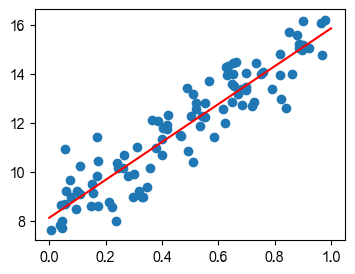

In [7]:
epoches = 10000

t0 = 5
t1 = 1000
def learning_rate_schedule(t): # 可以被叫做逆时衰减函数
    return t0 / (t + t1)

#要求解的系数
theta = np.random.randn(2, 1)

times = 0
for i in range(epoches):
    #计算梯度
    g = X.T @ (X @ theta - y)
    #更新 theta
    lr = learning_rate_schedule(times)
    theta = theta - lr * g
    times += 1

print('真实的斜率和截距为', w, b)
print('求出的斜率和截距为', theta.flatten())

# ------------------------

plt.figure(figsize = (4, 3))
_ = plt.scatter(X[:, [0]], y)

x2 = np.array([0, 1])
_ = plt.plot(x2, x2 * theta[0] + theta[1], color = 'red')

#### 多元一次线性回归

<font size=5>$y_{(m,1)} = X_{(m,n)}w_{(n,1)} + b + noise_{(m,1)}$</font>

In [8]:
m = 100 # 样本数
n = 10 #特征数
X = np.random.rand(m, n)
w = np.random.randint(1, 10, size = (n, 1)) # 随机斜率
b = np.random.randint(1, 10, size = 1)[0] # 随机截距

y = X @ w + b + np.random.randn(m, 1)

# ------------------------------

X = np.concatenate([X, np.full(shape = (m, 1), fill_value = 1)], axis = 1)

epoches = 10000

t0 = 5
t1 = 1000
def learning_rate_schedule(t): # 逆时衰减函数
    return t0 / (t + t1)

#要求解的系数数组，[theta_1, theta_2, ..., theta_n, theta_0]，最后一个 theta_0 呼应上边添加的一列
theta = np.random.randn(n + 1, 1)

times += 0
for i in range(epoches):
    #计算梯度
    g = X.T @ (X @ theta - y)
    #更新 theta
    lr = learning_rate_schedule(times)
    theta = theta - lr * g
    times += 1

print('真实的斜率和截距为', w.flatten(), b)
print('求出的斜率和截距为', theta.flatten())
print('偏差为', np.concatenate([w.flatten().reshape(1, -1), np.array([b]).reshape(1, -1)], axis = 1).flatten() - theta.flatten())

真实的斜率和截距为 [6 6 7 4 9 9 6 9 5 4] 4
求出的斜率和截距为 [6.07295779 6.78309825 7.03890545 4.65343829 8.96855287 8.80024085
 6.2605074  8.68728894 4.96670744 4.45913122 3.37688115]
偏差为 [-0.07295779 -0.78309825 -0.03890545 -0.65343829  0.03144713  0.19975915
 -0.2605074   0.31271106  0.03329256 -0.45913122  0.62311885]


### SGD 随机梯度下降

<font size=6>$\theta_k^{t+1} = \theta_k^{t} - \alpha * ((\sum \limits_{j=0}^n \theta_jx_j^{(i)} - y^{(i)}) x_k^{(i)})$</font>

#### 一元一次线性回归

真实的斜率和截距为 8 3
求出的斜率和截距为 [5.8237823  4.16895446]


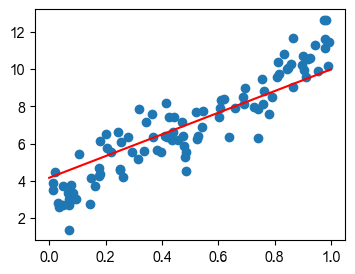

In [9]:
X = np.random.rand(100, 1)
w, b = np.random.randint(1, 10, size = 2)

y = w * X + b + np.random.randn(100, 1)

# ------------------------------

#添加截距列
X = np.concatenate([X, np.full(shape = (100, 1), fill_value = 1)], axis = 1)
epoches = 10000

t0 = 5
t1 = 1000
def learning_rate_schedule(t): # 可以被叫做逆时衰减函数
    return t0 / (t + t1)

#要求解的系数
theta = np.random.randn(2, 1)

times = 0
for i in range(epoches):
    #随机取出一个样本
    idx = np.random.randint(0, 100, size = 1)[0]
    X_random = X[[idx]] # (1,2)
    y_random = y[[idx]] # (1,1)
    #计算梯度
    g = X_random.T @ (X_random @ theta - y_random)
    #更新 theta
    lr = learning_rate_schedule(times)
    theta = theta - lr * g
    times += 1

print('真实的斜率和截距为', w, b)
print('求出的斜率和截距为', theta.flatten())

# ------------------------

plt.figure(figsize = (4, 3))
_ = plt.scatter(X[:, [0]], y)

x2 = np.array([0, 1])
_ = plt.plot(x2, x2 * theta[0] + theta[1], color = 'red')

#### 多元一次线性回归

In [10]:
m = 100 # 样本数
n = 10 #特征数
X = np.random.rand(m, n)
w = np.random.randint(1, 10, size = (n, 1)) # 随机斜率
b = np.random.randint(1, 10, size = (1, 1))[0] # 随机截距

y = X @ w + b + np.random.randn(m, 1)

# ------------------------------

#添加截距列
X = np.concatenate([X, np.full(shape = (m, 1), fill_value = 1)], axis = 1)

epoches = 10000

t0 = 5
t1 = 1000
def learning_rate_schedule(t): # 逆时衰减函数
    return t0 / (t + t1)

#要求解的系数数组，[theta_1, theta_2, ..., theta_n, theta_0]，最后一个 theta_0 呼应上边添加的一列
theta = np.random.randn(n + 1, 1)

times += 0
for i in range(epoches):
    #随机取出一个样本
    idx = np.random.randint(0, m, size = 1)[0]
    X_random = X[[idx]] # (1, n+1)
    y_random = y[[idx]] # (1, 1)
    #计算梯度
    g = X_random.T @ (X_random @ theta - y_random)
    #更新 theta
    lr = learning_rate_schedule(times)
    theta = theta - lr * g
    times += 1

print('真实的斜率和截距为', w.flatten(), b)
print('求出的斜率和截距为', theta.flatten())

真实的斜率和截距为 [6 1 2 7 7 8 4 2 6 5] [3]
求出的斜率和截距为 [3.8502448  3.70163228 3.26999611 4.86061925 5.21721701 5.56838373
 3.86554986 4.03149036 4.98815926 4.86232651 4.91942342]


### MBGD 小批量梯度下降

#### 一元一次线性回归

In [11]:
X = np.random.rand(100, 1)
w, b = np.random.randint(1, 10, size = 2)

y = w * X + b + np.random.randn(100, 1)

# ------------------------------

#添加截距列
X = np.concatenate([X, np.full(shape = (100, 1), fill_value = 1)], axis = 1)
epoches = 10000

t0 = 5
t1 = 1000
def learning_rate_schedule(t): # 可以被叫做逆时衰减函数
    return t0 / (t + t1)

#要求解的系数
theta = np.random.randn(2, 1)

batch_size = 16 # 每批样本数
batch_num = 100 // batch_size # 一共多少批

times = 0
for i in range(epoches):
    #随机取出一批
    batch_idx_start = np.random.randint(0, batch_size * batch_num, size = 1)[0]
    X_batch = X[batch_idx_start : (batch_idx_start + batch_size)]
    y_batch = y[batch_idx_start : (batch_idx_start + batch_size)]
    #计算梯度
    g = X_batch.T @ (X_batch @ theta - y_batch)
    #更新 theta
    lr = learning_rate_schedule(times)
    theta = theta - lr * g
    times += 1

print('真实的斜率和截距为', w, b)
print('求出的斜率和截距为', theta.flatten())

真实的斜率和截距为 4 4
求出的斜率和截距为 [3.54784163 4.20316665]


#### 多元一次线性回归

In [12]:
m = 100 # 样本数
n = 10 #特征数
X = np.random.rand(m, n)
w = np.random.randint(1, 10, size = (n, 1)) # 随机斜率
b = np.random.randint(1, 10, size = (1, 1))[0] # 随机截距

y = X @ w + b + np.random.randn(m, 1)

# ------------------------------

#添加截距列
X = np.concatenate([X, np.full(shape = (m, 1), fill_value = 1)], axis = 1)

epoches = 10000

t0 = 5
t1 = 1000
def learning_rate_schedule(t): # 逆时衰减函数
    return t0 / (t + t1)

#要求解的系数数组，[theta_1, theta_2, ..., theta_n, theta_0]，最后一个 theta_0 呼应上边添加的一列
theta = np.random.randn(n + 1, 1)

batch_size = 16 # 每批样本数
batch_num = m // batch_size # 一共多少批

times += 0
for i in range(epoches):
    #随机取出一批
    batch_idx_start = np.random.randint(0, batch_size * batch_num, size = 1)[0]
    X_batch = X[batch_idx_start : (batch_idx_start + batch_size)]
    y_batch = y[batch_idx_start : (batch_idx_start + batch_size)]
    #计算梯度
    g = X_random.T @ (X_random @ theta - y_random)
    #更新 theta
    lr = learning_rate_schedule(times)
    theta = theta - lr * g
    times += 1

print('真实的斜率和截距为', w.flatten(), b)
print('求出的斜率和截距为', theta.flatten())

真实的斜率和截距为 [4 5 1 7 8 5 7 2 5 1] [7]
求出的斜率和截距为 [1.6302179  2.00301814 4.99326948 2.79418998 1.10022507 2.43400783
 1.36794599 3.70985908 5.3200851  3.34873694 6.08515107]


## 归一化